## Exercise 06.02. (Assignment #01) Simple Linear Regression (15-20 minutes)
In this exercise, you will implement and evaluate a simple linear regression model using the Scikit-
Learn library. You will predict the MedHouseVal (Median House Value) in California based
on a single predictor variable from the dataset.

In [15]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import matplotlib.pyplot as plt
import pandas as pd

housing = fetch_california_housing(as_frame=True)
df = housing.frame                        # attribute holding features + target together
y = df["MedHouseVal"]

Model performance
R² (train): 0.025
R² (test):  0.014
MAE (test): 0.889
MSE (test): 1.292


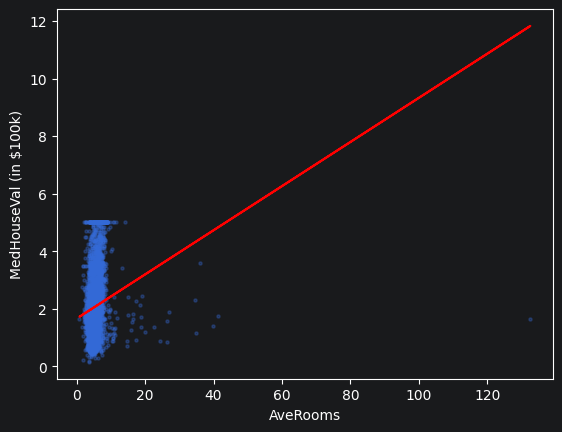

In [16]:
# AveRooms as the single predictor (double brackets keep it a DataFrame, which sklearn expects)
X_s = df[["AveRooms"]]

# 80/20 split, random_state fixed so the split is reproducible and matches 06.03
X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(X_s, y, test_size=0.2, random_state=42)

# Fit the line: finds the slope and intercept that minimize squared error on the training set
simple = LinearRegression().fit(X_s_train, y_s_train)

# Predict on both sets so train and test R² can be compared
y_s_train_pred = simple.predict(X_s_train)
y_s_test_pred = simple.predict(X_s_test)

# R² = share of variance explained, MAE = average error, MSE = squared error (punishes big misses)
print("Model performance")
print(f"R² (train): {r2_score(y_s_train, y_s_train_pred):.3f}")
print(f"R² (test):  {r2_score(y_s_test, y_s_test_pred):.3f}")
print(f"MAE (test): {mean_absolute_error(y_s_test, y_s_test_pred):.3f}")
print(f"MSE (test): {mean_squared_error(y_s_test, y_s_test_pred):.3f}")

# Scatter of the actual test data with the fitted regression line on top
plt.scatter(X_s_test, y_s_test, s=5, alpha=0.3)
plt.plot(X_s_test, y_s_test_pred, color="red")
plt.xlabel("AveRooms")
plt.ylabel("MedHouseVal (in $100k)")
plt.show()

## Exercise 06.03. (Assignment #01) Multiple Linear Regression (20-25 minutes)
In this exercise, you will implement and evaluate a multiple linear regression model using the Scikit-
Learn library. You will predict the MedHouseVal (Median House Value) in California based
on multiple predictor variables from the dataset.

In [17]:
# The four predictors from the assignment
X = df[["AveRooms", "AveOccup", "HouseAge", "AveBedrms"]]

# 80/20 split, same random_state as in 06.02 so both models are tested on the same rows
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model, finds one coefficient per predictor plus an intercept that minimize squared error
model = LinearRegression().fit(X_train, y_train)

# Predict on both sets so train and test R² can be compared (a big gap would mean overfitting)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# R² = share of variance explained, MAE = mean average error, MSE = mean squared error
print("Model performance")
print(f"R² (train): {r2_score(y_train, y_train_pred):.3f}")
print(f"R² (test):  {r2_score(y_test, y_test_pred):.3f}")
print(f"MAE (test): {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"MSE (test): {mean_squared_error(y_test, y_test_pred):.3f}")

# Coefficients, change in MedHouseVal (in $100k) per unit increase, holding the other predictors constant
print("\nCoefficients")
for name, coef in zip(X.columns, model.coef_):
    print(f"{name:<10} {coef:>8.4f}")

# VIF measures how well each predictor can be explained by the others (1 = no overlap)
# add_constant is needed because VIF is computed from regressions with an intercept
X_const = add_constant(X)
vif = pd.Series(
    [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
    index=X_const.columns,
)

# The constants VIF isn't meaningful, so it is left out.
print("\nVIF (above 5-10 = multicollinearity)")
print(vif.drop("const").round(2))

Model performance
R² (train): 0.164
R² (test):  0.139
MAE (test): 0.826
MSE (test): 1.128

Coefficients
AveRooms     0.3473
AveOccup    -0.0025
HouseAge     0.0150
AveBedrms   -1.6992

VIF (above 5-10 = multicollinearity)
AveRooms     3.65
AveOccup     1.00
HouseAge     1.03
AveBedrms    3.59
dtype: float64


## Exercise 06.03 Expected output/questions:

1. The R squared score is 0.164 on the training set and 0.139 on the test set. The scores are close, so there is no overfitting, but the model only explains about 14% of the variation.
2. The MAE drops from 0.889 to 0.826 and the MSE from 1.292 to 1.128, so the multiple model is better on both metrics, but only slightly.
3. Yes, AveRooms and AveBedrms have a correlation of 0.85 and VIF values of [X] and [Y], higher than the other predictors. This makes the coefficients unreliable, which is why AveBedrms gets a negative coefficient of about 1.7. It could be fixed by dropping one variable, combining them, or using regularization.

In [22]:
# Correlation
df[["AveRooms", "AveBedrms", "MedHouseVal"]].corr()

,AveRooms,AveBedrms,MedHouseVal
AveRooms,1.000000,0.847621,0.151948
AveBedrms,0.847621,1.000000,-0.046701
MedHouseVal,0.151948,-0.046701,1.000000
